In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/drug-sales.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

print("Data loaded successfully")
print(f"Total months: {len(df)}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

ModuleNotFoundError: No module named 'statsmodels'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/drug-sales.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

print("Data loaded successfully")
print(f"Total months: {len(df)}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Data loaded successfully
Total months: 204
Date range: 1991-07-01 00:00:00 to 2008-06-01 00:00:00


In [3]:
# Split data into training and test sets
# Train on first 180 months, test on last 24 months
train = df.iloc[:180]
test = df.iloc[180:]

print(f"Training data: {len(train)} months ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test data:     {len(test)} months ({test.index.min().date()} to {test.index.max().date()})")
print()
print("Now training the SARIMA model — this may take 30-60 seconds...")

# Train SARIMA model
# (1,1,1) = trend parameters
# (1,1,1,12) = seasonal parameters with 12 month cycle
model = SARIMAX(train['value'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12))

model_fit = model.fit(disp=False)
print("Model trained successfully!")

Training data: 180 months (1991-07-01 to 2006-06-01)
Test data:     24 months (2006-07-01 to 2008-06-01)

Now training the SARIMA model — this may take 30-60 seconds...
Model trained successfully!


In [4]:
# Generate predictions for the test period
predictions = model_fit.forecast(steps=len(test))
predictions.index = test.index

# Calculate accuracy
mae = np.mean(np.abs(predictions - test['value']))
pct_error = np.mean(np.abs(predictions - test['value']) / test['value']) * 100

print(f"Model accuracy results:")
print(f"  Mean Absolute Error: {mae:.2f}")
print(f"  Average % error:     {pct_error:.1f}%")
print(f"  Accuracy:            {100-pct_error:.1f}%")

Model accuracy results:
  Mean Absolute Error: 2.63
  Average % error:     11.7%
  Accuracy:            88.3%


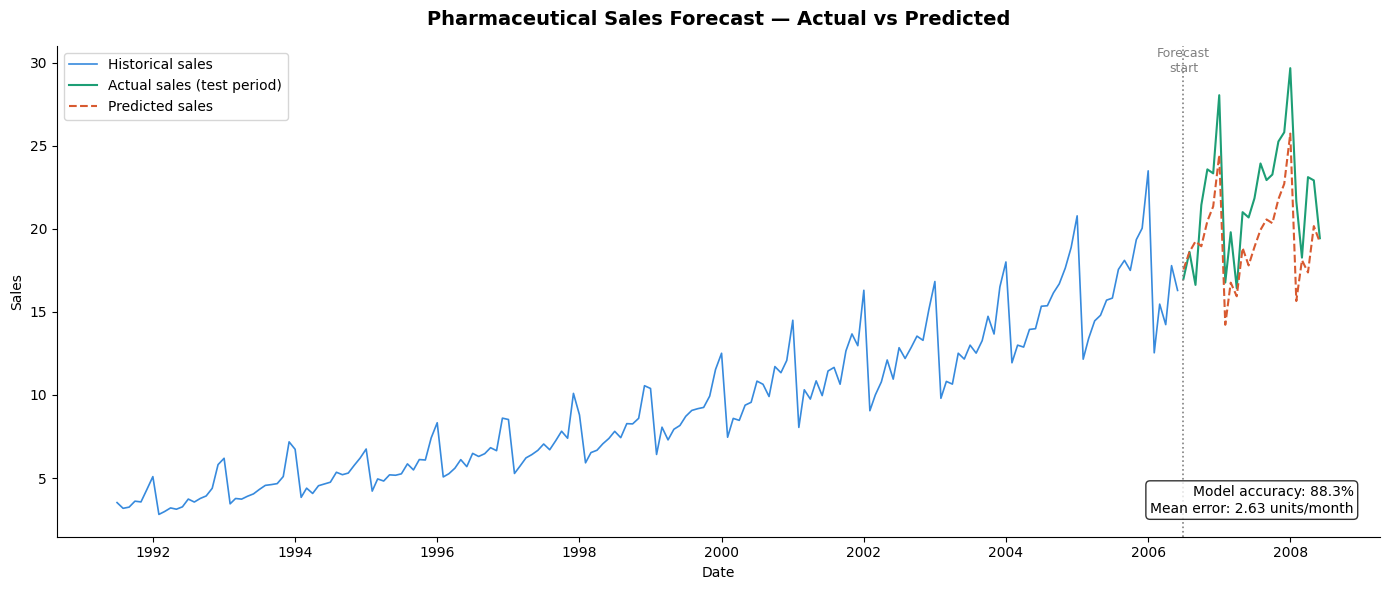

Chart saved.


In [5]:
# Final chart: Actual vs Predicted sales
fig, ax = plt.subplots(figsize=(14, 6))

# Plot full historical data
ax.plot(train.index, train['value'],
        color='#378ADD', linewidth=1.2, label='Historical sales')

# Plot actual test data
ax.plot(test.index, test['value'],
        color='#1D9E75', linewidth=1.5, label='Actual sales (test period)')

# Plot predictions
ax.plot(predictions.index, predictions.values,
        color='#D85A30', linewidth=1.5, linestyle='--', label='Predicted sales')

# Add vertical line showing train/test split
ax.axvline(x=test.index[0], color='gray', linestyle=':', linewidth=1.2)
ax.text(test.index[0], ax.get_ylim()[1]*0.95, 
        'Forecast\nstart', fontsize=9, color='gray', ha='center')

ax.set_title('Pharmaceutical Sales Forecast — Actual vs Predicted', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add accuracy annotation
ax.annotate('Model accuracy: 88.3%\nMean error: 2.63 units/month',
            xy=(0.98, 0.05), xycoords='axes fraction',
            fontsize=10, ha='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('../outputs/03_forecast_vs_actual.png', dpi=150)
plt.show()
print("Chart saved.")